# **Exploração e Análise do Dataset**

Notebook que combina:
1. **Exploração básica** — Carregamento, distribuição de classes, contagem de palavras
2. **Extração de features** — TF-IDF + 24 métricas comportamentais/estilísticas
3. **Visualização analítica** — Heatmap (impressão digital das IAs), boxplots das métricas mais discriminativas
4. **Preparação dos dados** — Split treino/validação/teste para os modelos

### **1. Imports e Configuração**

In [10]:
import math
import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from spellchecker import SpellChecker
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler

# Downloads do NLTK (silenciosos)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

### **2. Carregamento do Dataset**

In [11]:
df = pd.read_csv("../data/dataset.csv", sep=";").dropna()

# Normalizar nomes das colunas para minúsculas
df.columns = df.columns.str.lower()

print(f"✅ Dataset carregado com sucesso! Total de textos: {len(df)}")
print(f"✅ Classes presentes: {df['label'].unique()}")
print(f"\n📊 Distribuição de classes:")
print(df['label'].value_counts())

df.head()

✅ Dataset carregado com sucesso! Total de textos: 5000
✅ Classes presentes: ['OpenAI' 'Anthropic' 'Google' 'Meta' 'Human']

📊 Distribuição de classes:
label
OpenAI       1000
Anthropic    1000
Google       1000
Meta         1000
Human        1000
Name: count, dtype: int64


,id,text,label
0,D1-1,Cell mechanics pertains to the study of the ph...,OpenAI
1,D1-2,A knockout is a genetic engineering technique ...,Anthropic
2,D1-3,Electrode potential refers to the electric pot...,Anthropic
3,D1-4,A pseudogene is a segment of DNA that resemble...,OpenAI
4,D1-5,White matter in the central nervous system con...,Google


### **3. Exploração Básica**
#### **3.1 Distribuição de Classes**

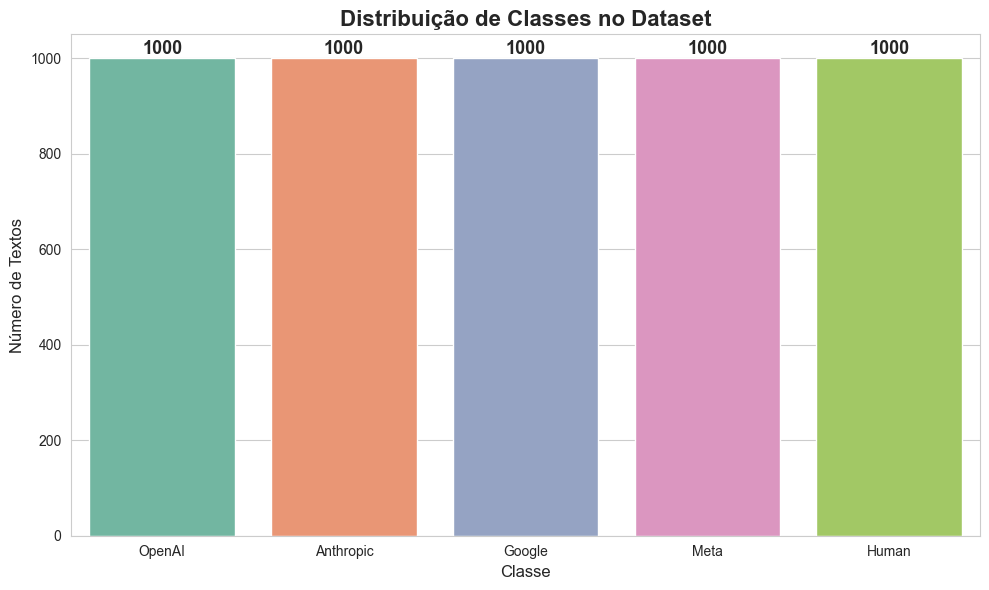

In [12]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='label', palette='Set2', hue='label', legend=False, order=df['label'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.title('Distribuição de Classes no Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Número de Textos', fontsize=12)
plt.tight_layout()
plt.show()

#### **3.2 Distribuição do Número de Palavras por Classe**

📏 Mínimo de palavras detetado globalmente: 80
📏 Máximo de palavras detetado globalmente: 120


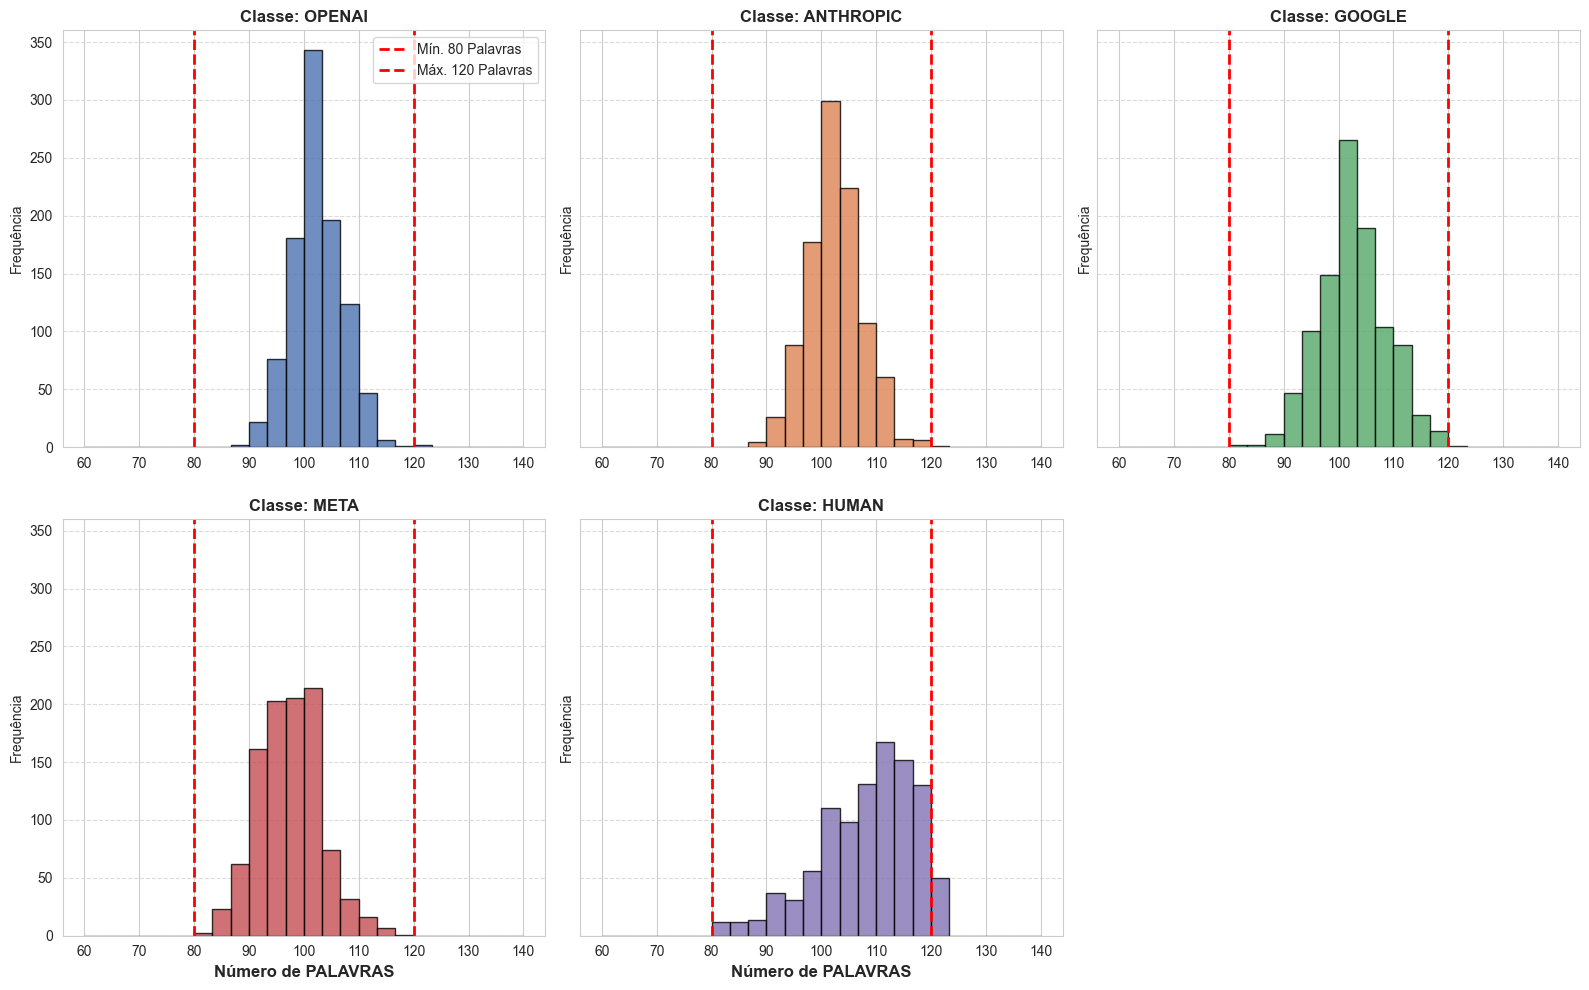

In [13]:
# Contar palavras por texto
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(f"📏 Mínimo de palavras detetado globalmente: {df['word_count'].min()}")
print(f"📏 Máximo de palavras detetado globalmente: {df['word_count'].max()}")

# Grelha de histogramas (2x3, 5 classes + 1 vazio)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()
cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
bins_globais = np.linspace(60, 140, 25) 

for i, classe in enumerate(df['label'].unique()):
    ax = axes[i]
    dados_classe = df[df['label'] == classe]['word_count']
    
    ax.hist(dados_classe, bins=bins_globais, alpha=0.8, color=cores[i % len(cores)], edgecolor='black')
    
    # Linhas vermelhas: limites do professor (80-120 palavras)
    ax.axvline(x=80, color='red', linestyle='dashed', linewidth=2, label='Mín. 80 Palavras')
    ax.axvline(x=120, color='red', linestyle='dashed', linewidth=2, label='Máx. 120 Palavras')
    
    ax.set_title(f'Classe: {classe.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequência', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(labelbottom=True)
    
    if i == 0:
        ax.legend()

# Apagar o 6º gráfico (vazio)
fig.delaxes(axes[5])

for ax in axes[-3:]:
    ax.set_xlabel('Número de PALAVRAS', fontsize=12, fontweight='bold')

plt.tight_layout(h_pad=2.0)
plt.show()

### **4. Extração de Features**

In [14]:
class TextFeatureExtractor:
    """
    Extrai TF-IDF + 24 métricas comportamentais/estilísticas de cada texto.
    Métricas incluídas:
    - Burstiness, Typos Ratio, Word Entropy, TTR, Avg Word/Sentence Length
    - Buzzword Ratio, Adjective Ratio, Punctuation Ratio
    - Bigram Ratio, Trigram Density, Perplexity, POS Entropy
    - Rhythm Variance, Stopword Ratio, Rare Word Ratio
    - Function Word Ratio & Entropy, Repetition Distance, Sentence Length Entropy
    - GLTR (Top 10, Top 100, Top 1000, Rest)
    """
    def __init__(self, max_vocab=1500):
        self.max_vocab = max_vocab
        self.spell = SpellChecker()
        self.vocab = None
        self.vocab_set = None
        self.idf = None
        
        # Tracking GLTR
        self.unigram_counts = Counter()
        self.bigram_counts = Counter()
        self.bigram_ranks = {}
        
        self.stopwords = set(stopwords.words("english"))
        self.LLM_BUZZWORDS = {
            'furthermore','moreover','delve','tapestry',
            'testament','pivotal','underscore','multifaceted',
            'crucial','consequently'
        }
        self.FUNCTION_WORDS = {
            'the','of','to','and','a','in','that','is','it','for','on','with',
            'as','at','this','by','from','or','an','be','are','was','were'
        }

    def _get_gltr_metrics(self, words):
        """Calcula a distribuição de GLTR (Top 10, Top 100, etc.)"""
        if len(words) < 2 or not self.bigram_ranks:
            return 0, 0, 0, 0
            
        bigrams = list(zip(words, words[1:]))
        top_10 = top_100 = top_1000 = rest = 0
        
        for w1, w2 in bigrams:
            rank = self.bigram_ranks.get((w1, w2), None)
            if rank is None:
                rest += 1
            elif rank <= 10:
                top_10 += 1
            elif rank <= 100:
                top_100 += 1
            elif rank <= 1000:
                top_1000 += 1
            else:
                rest += 1
                
        total = len(bigrams)
        return top_10/total, top_100/total, top_1000/total, rest/total

    def _get_metrics(self, text):
        sentences = sent_tokenize(text)
        raw_tokens = word_tokenize(text)
        words = [w.lower() for w in raw_tokens if w.isalpha()]
        
        if not words:
            return [0] * 24

        # Basic Metrics
        s_lengths = [len(word_tokenize(s)) for s in sentences]
        burst = np.std(s_lengths) if len(sentences) > 1 else 0
        typos = len(self.spell.unknown(words)) / len(words)
        counts = Counter(words)
        total = len(words)
        ent = sum(-(c/total)*math.log2(c/total) for c in counts.values())
        ttr_val = len(set(words))/len(words)
        awl = np.mean([len(w) for w in words])
        asl = len(words)/len(sentences) if sentences else 0
        buzz = sum(w in self.LLM_BUZZWORDS for w in words)/len(words)
        
        tags = nltk.pos_tag(raw_tokens)
        adj = sum(tag.startswith('JJ') for _,tag in tags)/len(raw_tokens) if raw_tokens else 0
        punct = (text.count('!') + text.count('?') + text.count('...')) / len(text) if text else 0

        # Ngram Features
        bigrams = list(zip(words, words[1:]))
        unique_bigrams = len(set(bigrams))
        bigram_ratio = unique_bigrams / len(bigrams) if bigrams else 0
        text_clean = text.replace(" ", "_")
        char_trigrams = [text_clean[i:i+3] for i in range(len(text_clean)-2)]
        char_trigram_density = len(set(char_trigrams)) / len(char_trigrams) if char_trigrams else 0

        # Perplexity
        unigram_counts = Counter(words)
        bigram_counts = Counter(bigrams)
        log_prob_sum = 0
        N = len(bigrams)
        for w1, w2 in bigrams:
            p = (bigram_counts[(w1,w2)] + 1) / (unigram_counts[w1] + len(unigram_counts))
            log_prob_sum += math.log2(p)
        perplexity = 2 ** (-log_prob_sum / N) if N > 0 else 0

        # POS features
        pos_tags = [tag for _,tag in tags]
        pos_counts = Counter(pos_tags)
        pos_total = len(pos_tags)
        pos_entropy = sum(-(c/pos_total)*math.log2(c/pos_total) for c in pos_counts.values())

        # Rhythm Variance, Stopword Ratio, Rare Word Ratio
        rhythm_var = np.var(s_lengths) if len(s_lengths) > 1 else 0
        stop_ratio = sum(w in self.stopwords for w in words)/len(words)
        rare_words = [w for w,c in counts.items() if c == 1]
        rare_ratio = len(rare_words)/len(words)

        # Function Word Ratio & Entropy
        fw = [w for w in words if w in self.FUNCTION_WORDS]
        fw_ratio = len(fw) / len(words)
        if fw:
            fw_counts = Counter(fw)
            fw_total = len(fw)
            fw_entropy = sum(-(c/fw_total)*math.log2(c/fw_total) for c in fw_counts.values())
        else:
            fw_entropy = 0

        # Repetition Distance
        last_seen = {}
        distances = []
        for i, w in enumerate(words):
            if w in last_seen:
                distances.append(i - last_seen[w])
            last_seen[w] = i
        rep_distance = np.mean(distances) if distances else 0

        # Sentence Length Entropy
        if s_lengths:
            sl_counts = Counter(s_lengths)
            sl_total = len(s_lengths)
            sl_entropy = sum(-(c/sl_total)*math.log2(c/sl_total) for c in sl_counts.values())
        else:
            sl_entropy = 0

        # GLTR Approach
        gltr_top10, gltr_top100, gltr_top1000, gltr_rest = self._get_gltr_metrics(words)

        return [
            burst, typos, ent, ttr_val, awl, asl, buzz, adj, punct,
            bigram_ratio, char_trigram_density, perplexity, pos_entropy,
            rhythm_var, stop_ratio, rare_ratio,
            fw_ratio, fw_entropy, rep_distance, sl_entropy,
            gltr_top10, gltr_top100, gltr_top1000, gltr_rest
        ]

    def fit_tfidf(self, corpus):
        tokenized = [re.findall(r'\b[a-zA-Z]+\b', doc.lower()) for doc in corpus]
        doc_freq = Counter()
        
        for doc in tokenized:
            for word in set(doc):
                doc_freq[word] += 1
            # Tracking GLTR
            self.unigram_counts.update(doc)
            self.bigram_counts.update(zip(doc, doc[1:]))
            
        self.vocab = [w for w, _ in doc_freq.most_common(self.max_vocab)]
        self.vocab_set = set(self.vocab)
        N = len(corpus)
        self.idf = {w: math.log((1+N)/(1+doc_freq[w])) + 1 for w in self.vocab}
        
        # Calculate bigram ranks for GLTR
        following_dict = defaultdict(list)
        for (w1, w2), count in self.bigram_counts.items():
            following_dict[w1].append((w2, count))
            
        self.bigram_ranks = {}
        for w1, following in following_dict.items():
            following.sort(key=lambda x: x[1], reverse=True) 
            for rank, (w2, count) in enumerate(following):
                self.bigram_ranks[(w1, w2)] = rank + 1

    def transform_tfidf(self, corpus):
        matrix = []
        for doc in corpus:
            words = re.findall(r'\b[a-zA-Z]+\b', doc.lower())
            tf = Counter(words)
            length = len(words) if words else 1
            row = [(tf.get(w, 0)/length) * self.idf[w] for w in self.vocab]
            matrix.append(row)
        return np.array(matrix)

    def fit_transform(self, corpus):
        corpus = [str(t) for t in corpus]
        self.fit_tfidf(corpus)
        tfidf_matrix = self.transform_tfidf(corpus)
        behavioral_matrix = np.array([self._get_metrics(t) for t in corpus])
        return tfidf_matrix, behavioral_matrix

#### **4.1 Executar a Extração**

In [15]:
extractor = TextFeatureExtractor(max_vocab=1500)
print("A extrair TF-IDF e as métricas comportamentais...")

X_tfidf, X_extra = extractor.fit_transform(df["text"])

# Normalização das métricas comportamentais
scaler_comportamental = StandardScaler()
X_extra_norm = scaler_comportamental.fit_transform(X_extra)

# Concatenar: TF-IDF + Comportamentais
X_combined = np.hstack((X_tfidf, X_extra_norm))

print(f"✅ Features extraídas: {X_combined.shape[1]} ({X_tfidf.shape[1]} TF-IDF + {X_extra.shape[1]} comportamentais)")

A extrair TF-IDF e as métricas comportamentais...
✅ Features extraídas: 1524 (1500 TF-IDF + 24 comportamentais)


### **5. Visualização Analítica das Features**
#### **5.1 Impressão Digital das IAs (Heatmap)**

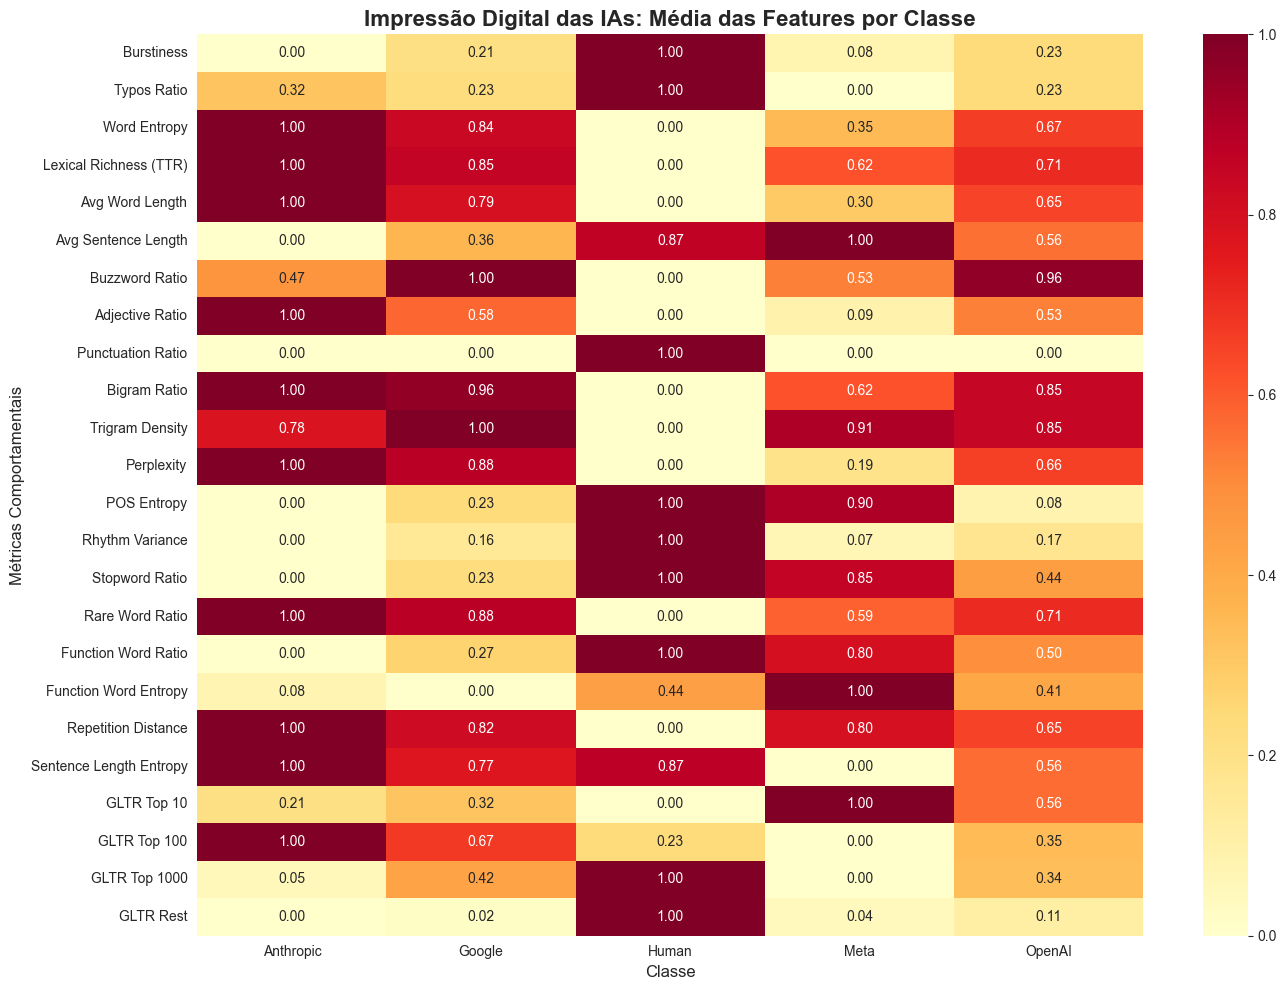

In [16]:
feature_names = [
    'Burstiness', 'Typos Ratio', 'Word Entropy', 'Lexical Richness (TTR)', 
    'Avg Word Length', 'Avg Sentence Length', 'Buzzword Ratio', 'Adjective Ratio', 'Punctuation Ratio',
    'Bigram Ratio', 'Trigram Density', 'Perplexity', 'POS Entropy',
    'Rhythm Variance', 'Stopword Ratio', 'Rare Word Ratio',
    'Function Word Ratio', 'Function Word Entropy', 'Repetition Distance', 'Sentence Length Entropy',
    'GLTR Top 10', 'GLTR Top 100', 'GLTR Top 1000', 'GLTR Rest'
]

df_visual = pd.DataFrame(X_extra, columns=feature_names)
df_visual['Classe'] = df['label'].values

# Média por classe, normalizada 0-1 para visualização
df_mean = df_visual.groupby('Classe').mean()
df_mean_scaled = (df_mean - df_mean.min()) / (df_mean.max() - df_mean.min())

plt.figure(figsize=(14, 10))
sns.heatmap(df_mean_scaled.T, cmap='YlOrRd', annot=True, fmt=".2f", cbar=True)
plt.title('Impressão Digital das IAs: Média das Features por Classe', fontsize=16, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Métricas Comportamentais', fontsize=12)
plt.tight_layout()
plt.show()

#### **5.2 Distribuição das Features Mais Discriminativas**

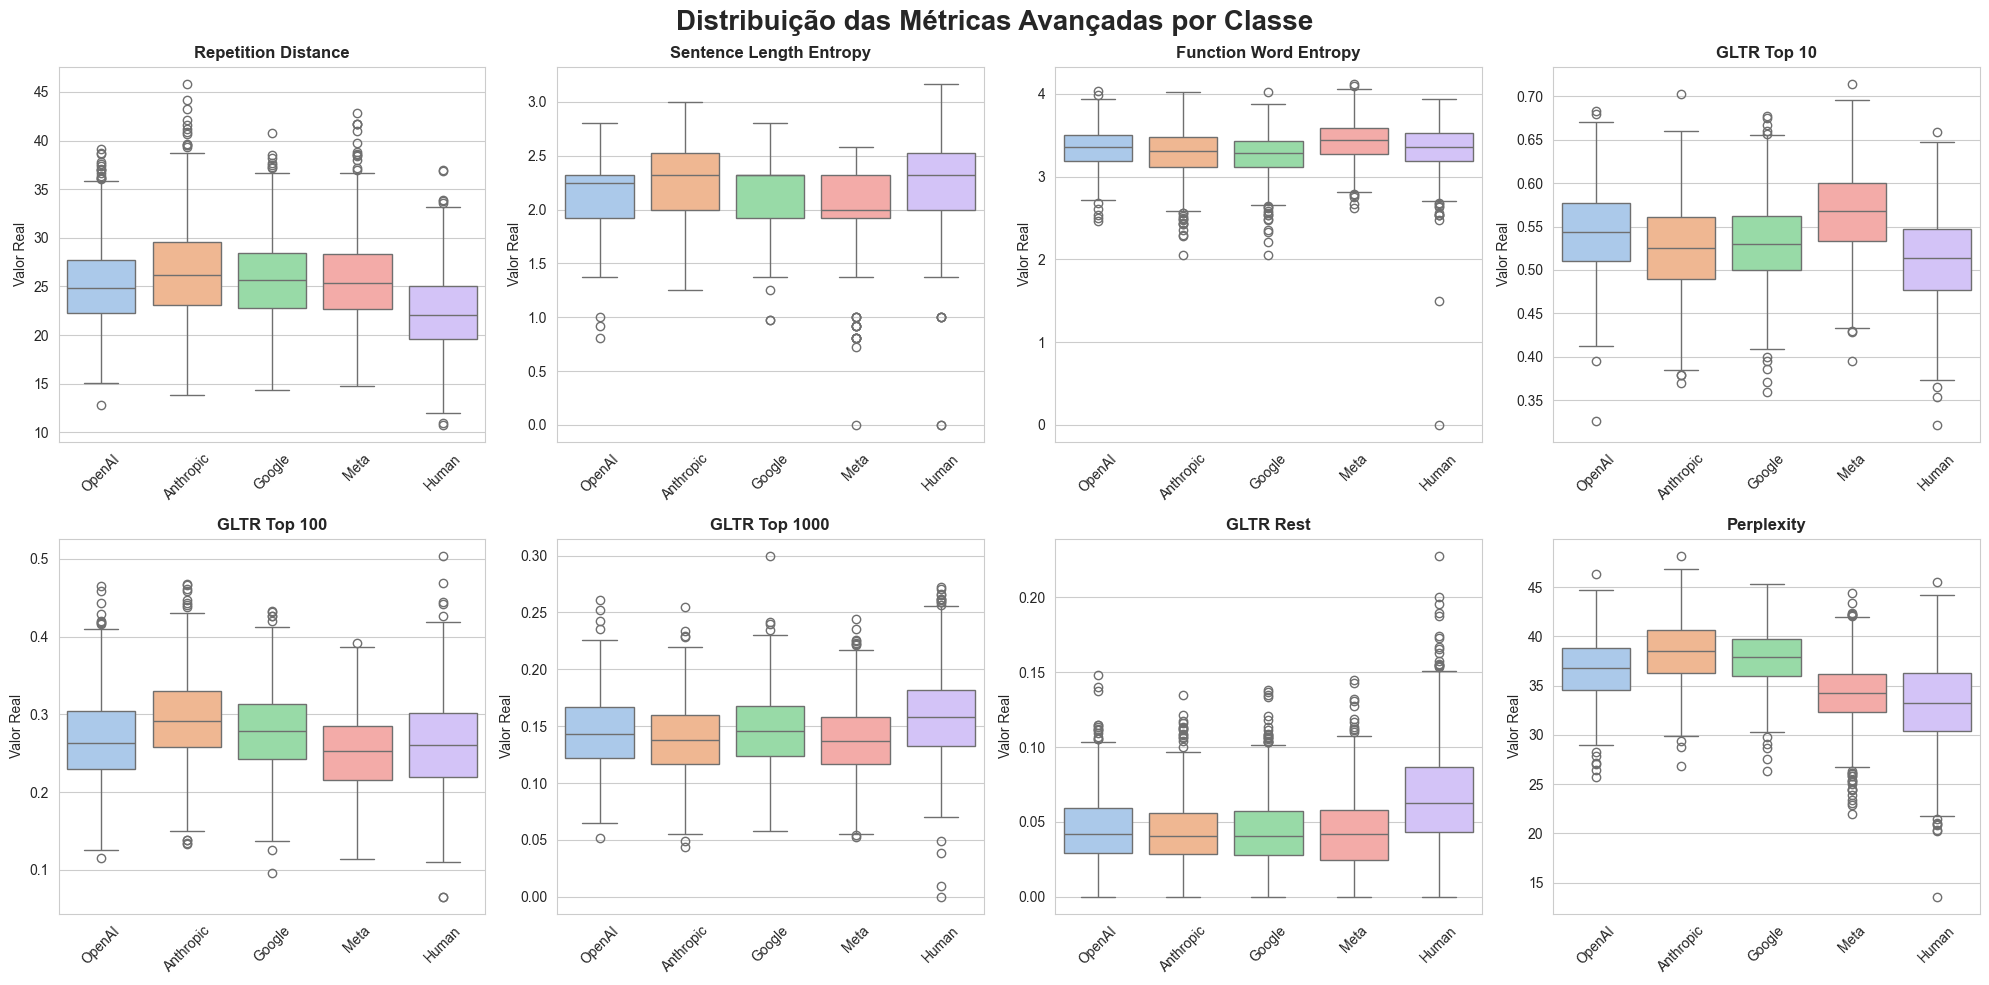

In [17]:
features_top8 = [
    'Repetition Distance', 'Sentence Length Entropy', 'Function Word Entropy',
    'GLTR Top 10', 'GLTR Top 100', 'GLTR Top 1000', 'GLTR Rest', 'Perplexity'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features_top8):
    sns.boxplot(x='Classe', y=feature, data=df_visual, ax=axes[i], palette='pastel', hue='Classe', legend=False)
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor Real')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribuição das Métricas Avançadas por Classe', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()